In [2]:
import matplotlib.pyplot as plt
import numpy as np
from time import time 
import functools

In [3]:
def time_cheak(func):
    @functools.wraps(func)
    def wrapper(*arg, **kwargs):
        Times = []
        for i in range(20):
            t = time()
            func(*arg, **kwargs)
            Times.append(time() - t)
        return sum(Times) / len(Times)
    return wrapper

In [4]:
# Data = [int(float(f"2e{i}")) for i in range(10)]
Data = [i for i in range(1, 1000000,10000)]

@time_cheak
def normal(data) -> None:
    x = []
    for i in range(data):
        x.append(i)


@time_cheak
def comprehension(data) -> None:
    x = [i for i in range(data)]

<class 'list'>
100 100


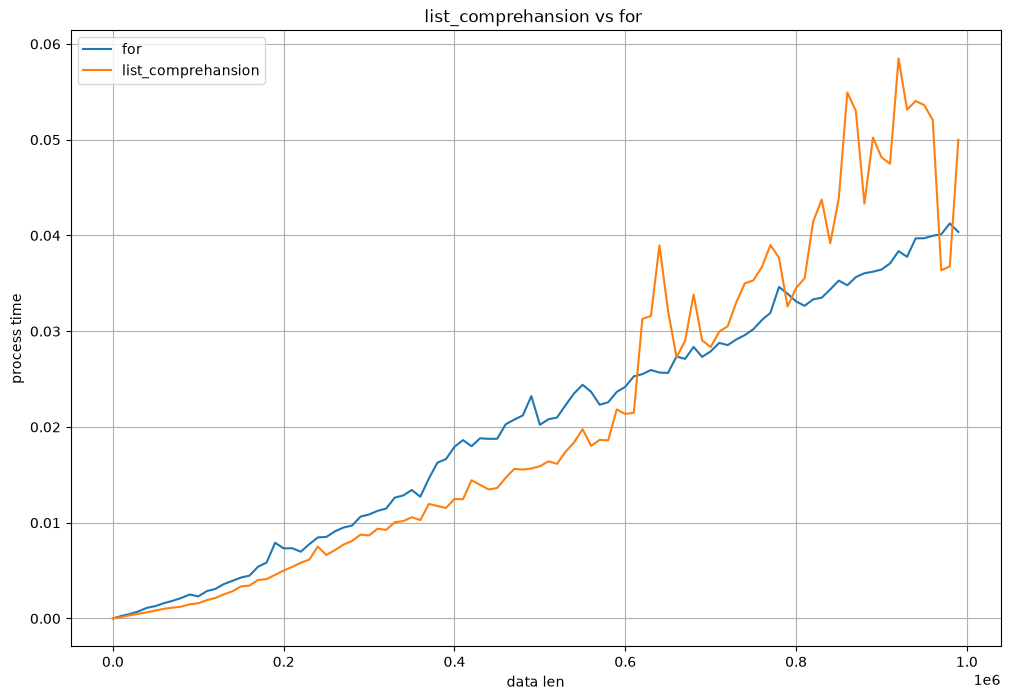

In [5]:
X = Data
print(type(Data))
y1 = [normal(x) for x in X]
y2 = [comprehension(x) for x in X]

print(len(y1), len(y2))

plt.figure(1, figsize=(12, 8))
plt.plot(X, y1, label="for")
plt.plot(X, y2, label="list_comprehansion")
plt.xlabel("data len")
plt.ylabel("process time")
plt.title("list_comprehansion vs for ")
plt.grid()
plt.legend()
plt.show()


**-> 즉 최소한 $10^6$까지는 리스트 컴프리헨션이 기본 for문보다 성능이 우세함**

우리가 쓰는 데이터셋 \
최대 150만 가량의 데이터 -> $150만 = 1,500,000 = 1.5 \times 10^5$
즉, 리스트 컴프리헨션으로 진행하는것이 성능이 더 좋을수 있음